In [32]:
# Creating classification models
# Creating the pipeline
# Importing libraries
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
print ("libraries were imported successfully...")

libraries were imported successfully...


In [33]:
house_data = pd.read_csv(r"..\raw_data\house_data.csv")
house_data.drop(["id", "date"], axis=1, inplace=True)

In [34]:
house_data['price_category'] = pd.qcut(house_data['price'], q=4, labels=['low', 'medium1','medium2','high'])
house_data['price_category'] = house_data['price_category'].astype('category')
house_data.groupby("price_category")['price'].median()\
    .reset_index()\
    .sort_values(by='price_category', ascending=True)\
    # .rename(columns={'index': 'price_category', 'price_category': 'count'})
house_data['price_category']=house_data['price_category'].cat.codes
house_data['price_category'].value_counts()

price_category
1    5460
0    5404
2    5376
3    5373
Name: count, dtype: int64

In [35]:
X = house_data.drop(["price","price_category"], axis=1)
y = house_data["price_category"]

In [36]:
print (*X.columns,sep="\n")

bedrooms
bathrooms
sqft_living
sqft_lot
floors
waterfront
view
condition
grade
sqft_above
sqft_basement
yr_built
yr_renovated
zipcode
lat
long
sqft_living15
sqft_lot15


In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [38]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("dim_reduction", PCA(n_components=3)),
    ("classifier", KMeans(n_clusters=4, random_state=42))
])

best_inertia=[]
for i in range(1,11):
    pipeline.set_params(classifier__n_clusters= i)
    pipeline.fit(X_train)
    best_inertia.append(pipeline.named_steps["classifier"].inertia_)
best_inertia



[150228.96927755862,
 95621.97493281092,
 78250.93474085687,
 65137.6702008971,
 51096.99754060093,
 44498.996701877186,
 39044.70890702715,
 35346.710527023104,
 32586.248822723395,
 29721.739560358325]

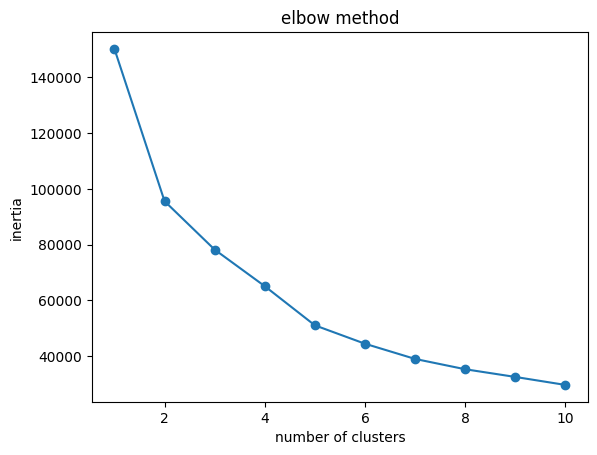

In [39]:
import matplotlib.pyplot as plt
plt.plot(range(1,11),best_inertia,marker='o')
plt.title("elbow method")
plt.xlabel("number of clusters")
plt.ylabel("inertia")
plt.show()

In [40]:
pipeline.set_params(classifier__n_clusters= 4)
pipeline.fit(X_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('dim_reduction', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",3
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'

In [41]:
labels = pipeline.named_steps['classifier'].labels_
print(labels)

[3 3 3 ... 3 2 3]


In [42]:
# dir(pipeline.named_steps['classifier'])

In [43]:
prediction = pipeline.predict(X_test)
inertia = pipeline.named_steps['classifier'].inertia_
print (inertia)

65137.6702008971


In [44]:
# attaching the cluster labels to the original dataset - X_train
X_train_clustered = X_train.copy()
X_train_clustered['cluster_labels'] = pipeline.named_steps['classifier'].labels_  
X_train_clustered.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,cluster_labels
5945,4,2.25,1810,9240,2.0,0,0,3,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240,3
8423,3,2.50,1600,2788,2.0,0,0,4,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605,3
13488,4,2.50,1720,8638,2.0,0,0,3,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455,3
20731,2,2.25,1240,705,2.0,0,0,3,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750,3
2358,3,2.00,1280,13356,1.0,0,0,3,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071,2


In [45]:
X_train_clustered.groupby('cluster_labels').mean()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
cluster_labels,,,,,,,,,,,,,,,,,,
0,3.890030,2.349039,2464.066247,10887.213647,1.286850,0.027493,0.721431,3.740311,7.780391,1658.523021,805.543226,1952.865518,250.674064,98101.155681,47.606632,-122.285768,2113.777410,9648.568069
1,4.137171,3.110140,3689.098978,51390.350188,1.889457,0.015600,0.603550,3.208176,9.556213,3273.906401,415.192577,1992.692846,74.185046,98049.455621,47.570441,-122.100751,3110.562130,39509.942442
2,2.851735,1.443608,1365.792808,10387.924917,1.134960,0.000158,0.047679,3.531760,6.782671,1194.392840,171.399968,1953.690638,62.785839,98090.667036,47.553222,-122.257815,1523.278315,9456.893395
3,3.417896,2.443902,2129.614787,9367.872658,1.939418,0.000000,0.039059,3.125947,7.966122,2051.735552,77.879235,1996.143683,9.972100,98058.625947,47.538886,-122.157665,2065.450379,8798.628936


In [46]:
X_train_clustered.groupby('cluster_labels').median()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
cluster_labels,,,,,,,,,,,,,,,,,,
0,4.0,2.5,2380.0,7912.0,1.0,0.0,0.0,4.0,8.0,1570.0,840.0,1957.0,0.0,98115.0,47.6294,-122.300,2050.0,7768.0
1,4.0,3.0,3530.0,14565.0,2.0,0.0,0.0,3.0,10.0,3230.0,0.0,1997.0,0.0,98045.0,47.5848,-122.100,3140.0,13525.0
2,3.0,1.5,1350.0,7482.0,1.0,0.0,0.0,3.0,7.0,1160.0,0.0,1955.0,0.0,98106.0,47.5557,-122.294,1490.0,7503.0
3,3.0,2.5,2100.0,6523.0,2.0,0.0,0.0,3.0,8.0,2020.0,0.0,2000.0,0.0,98052.0,47.5524,-122.164,2050.0,6551.0


In [47]:
cluster_labels=X_train_clustered.groupby('cluster_labels')[["bedrooms","bathrooms","sqft_living","sqft_lot","floors"]].agg(["mean","median"])
cluster_labels 

bedrooms        bathrooms         sqft_living          \
                    mean median      mean median         mean  median   
cluster_labels                                                          
0               3.890030    4.0  2.349039    2.5  2464.066247  2380.0   
1               4.137171    4.0  3.110140    3.0  3689.098978  3530.0   
2               2.851735    3.0  1.443608    1.5  1365.792808  1350.0   
3               3.417896    3.0  2.443902    2.5  2129.614787  2100.0   

                    sqft_lot             floors         
                        mean   median      mean median  
cluster_labels                                          
0               10887.213647   7912.0  1.286850    1.0  
1               51390.350188  14565.0  1.889457    2.0  
2               10387.924917   7482.0  1.134960    1.0  
3                9367.872658   6523.0  1.939418    2.0

In [48]:
cluster_lab = {
    0: "Spacious Single-Story Homes",
    1: "Large / Luxury Estates",
    2: "Compact Starter Homes",
    3: "Multi-Story Family Homes"
}
cluster_labels.index = cluster_labels.index.map(cluster_lab)
cluster_labels

cluster_labels


bedrooms        bathrooms         sqft_living  \
                                 mean median      mean median         mean   
cluster_labels                                                               
Spacious Single-Story Homes  3.890030    4.0  2.349039    2.5  2464.066247   
Large / Luxury Estates       4.137171    4.0  3.110140    3.0  3689.098978   
Compact Starter Homes        2.851735    3.0  1.443608    1.5  1365.792808   
Multi-Story Family Homes     3.417896    3.0  2.443902    2.5  2129.614787   

                                         sqft_lot             floors         
                             median          mean   median      mean median  
cluster_labels                                                               
Spacious Single-Story Homes  2380.0  10887.213647   7912.0  1.286850    1.0  
Large / Luxury Estates       3530.0  51390.350188  14565.0  1.889457    2.0  
Compact Starter Homes        1350.0  10387.924917   7482.0  1.134960    1.0  
Multi-Story Family Homes     2100.0   9367.872658   6523.0  1.939418    2.0